**Install required libraries**

In [ ]:
!pip -q install pandas numpy scikit-learn rank-bm25 sentence-transformers transformers accelerate torch matplotlib tqdm

**Import libraries**

In [ ]:
import re
import math
import time
import zipfile
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

**Upload and extract dataset ZIP**

In [ ]:
from google.colab import files

print("Upload your dataset ZIP file")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
extract_root = Path("/content")

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_root)

# Automatically find dataset folder
metadata_candidates = list(Path("/content").glob("**/processed/document_metadata.csv"))

if len(metadata_candidates) == 0:
    raise FileNotFoundError("document_metadata.csv not found. Check dataset ZIP structure.")

base_path = metadata_candidates[0].parents[1]
processed_path = base_path / "processed"
results_path = base_path / "results"
tables_path = results_path / "chapter4_tables"
plots_path = results_path / "chapter4_plots"

results_path.mkdir(exist_ok=True)
tables_path.mkdir(exist_ok=True)
plots_path.mkdir(exist_ok=True)

print("Dataset folder found:", base_path)

Upload your dataset ZIP file


Saving N6-rag_regulation_dataset.zip to N6-rag_regulation_dataset.zip
Dataset folder found: /content/rag_regulation_dataset_v1/rag_regulation_dataset


**Load dataset files**

In [ ]:
metadata = pd.read_csv(processed_path / "document_metadata.csv")
qa = pd.read_csv(processed_path / "qa_dataset.csv")

chunks_small = pd.read_csv(processed_path / "chunks_small.csv")
chunks_medium = pd.read_csv(processed_path / "chunks_medium.csv")
chunks_large = pd.read_csv(processed_path / "chunks_large.csv")

print("Documents:", len(metadata))
print("QA pairs:", len(qa))
print("Small chunks:", len(chunks_small))
print("Medium chunks:", len(chunks_medium))
print("Large chunks:", len(chunks_large))

display(metadata.head())
display(qa.head())
display(chunks_medium.head())

Documents: 20
QA pairs: 100
Small chunks: 684
Medium chunks: 428
Large chunks: 266


,doc_id,university_name,document_title,detected_title,document_type,programme,language,source_format,uploaded_format,source_url,file_name,raw_document_path,extracted_text_file,file_status
0,D001,TH Köln,Digital Sciences Examination Regulations,Examination regulations for the programs Digit...,Examination regulation,M.Sc. Digital Sciences,English,PDF,PDF,https://www.th-koeln.de/mam/downloads/englisch...,D001_thk_digital_sciences_exam_regulations.pdf,raw_documents/D001_thk_digital_sciences_exam_r...,extracted_text/D001.txt,available
1,D002,TH Köln,IWRM / NRM / REM Master Examination Regulations,Examination regulations for the Master’s progr...,Examination regulation,M.Sc. Natural Resources Management and Develop...,English,PDF,PDF,https://www.th-koeln.de/mam/downloads/englisch...,D002_thk_iwrm_nrm_rem_exam_regulations.pdf,raw_documents/D002_thk_iwrm_nrm_rem_exam_regul...,extracted_text/D002.txt,available
2,D003,TH Köln,International Business Master Module Handbook,International Business Master,Module handbook,International Business Master,English,PDF,PDF,https://www.th-koeln.de/mam/downloads/englisch...,D003_thk_international_business_module_handboo...,raw_documents/D003_thk_international_business_...,extracted_text/D003.txt,available
3,D004,TH Köln,Examination Management in CaMS,Examination management in CaMS Step-by-step in...,Exam guidance,General student examination services,English,PDF,PDF,https://www.th-koeln.de/mam/downloads/englisch...,D004_thk_cams_exam_management.pdf,raw_documents/D004_thk_cams_exam_management.pdf,extracted_text/D004.txt,available
4,D005,TH Köln,For Students,For Students,Student guidance / service page,General student information,English,HTML page saved as PDF,PDF,https://www.th-koeln.de/en/academics/for-stude...,D005_thk_for_students.pdf,raw_documents/D005_thk_for_students.pdf,extracted_text/D005.txt,available


,question_id,doc_id,university_name,document_title,programme,question_type,question,reference_answer,source_page,supporting_chunk_id_medium,source_url
0,Q001,D001,TH Köln,Digital Sciences Examination Regulations,M.Sc. Digital Sciences,scope,What is the scope or applicability of Digital ...,5 § 1 Applicability of the examination regulat...,5,C_MEDIUM_D001_001,https://www.th-koeln.de/mam/downloads/englisch...
1,Q002,D001,TH Köln,Digital Sciences Examination Regulations,M.Sc. Digital Sciences,objectives,What objectives or learning outcomes are descr...,5 § 2 Objectives of the program; purpose of ex...,5,C_MEDIUM_D001_001,https://www.th-koeln.de/mam/downloads/englisch...
2,Q003,D001,TH Köln,Digital Sciences Examination Regulations,M.Sc. Digital Sciences,degree,What academic degree or qualification is descr...,64/2021 Examination regulations for the progra...,1,C_MEDIUM_D001_001,https://www.th-koeln.de/mam/downloads/englisch...
3,Q004,D001,TH Köln,Digital Sciences Examination Regulations,M.Sc. Digital Sciences,duration,What duration or standard period of study is s...,6 § 4 Standard program duration (Regelstudienz...,5,C_MEDIUM_D001_001,https://www.th-koeln.de/mam/downloads/englisch...
4,Q005,D001,TH Köln,Digital Sciences Examination Regulations,M.Sc. Digital Sciences,admission,What admission or prerequisite information is ...,5 § 3 Admission requirements ....................,5,C_MEDIUM_D001_001,https://www.th-koeln.de/mam/downloads/englisch...


,chunk_id,doc_id,university_name,document_title,chunking_strategy,chunk_index,start_page,end_page,num_words,chunk_text
0,C_MEDIUM_D001_001,D001,TH Köln,Digital Sciences Examination Regulations,medium,1,1,5,500,Official Communication (Amtliche Mitteilung) N...
1,C_MEDIUM_D001_002,D001,TH Köln,Digital Sciences Examination Regulations,medium,2,5,7,500,of examinations; examination deadlines ..........
2,C_MEDIUM_D001_003,D001,TH Köln,Digital Sciences Examination Regulations,medium,3,7,8,500,one specialization. (2) Based on these examina...
3,C_MEDIUM_D001_004,D001,TH Köln,Digital Sciences Examination Regulations,medium,4,8,9,500,Science” is awarded in ac- cordance with the r...
4,C_MEDIUM_D001_005,D001,TH Köln,Digital Sciences Examination Regulations,medium,5,9,10,500,"services archi- tectures, IT security, IT arch..."


**Dataset validation and cleaning**

In [ ]:
required_qa_cols = ["question_id", "question", "reference_answer", "doc_id"]
required_chunk_cols = ["chunk_id", "doc_id", "chunk_text"]

for col in required_qa_cols:
    if col not in qa.columns:
        raise ValueError(f"Missing required QA column: {col}")

for df_name, df in {
    "chunks_small": chunks_small,
    "chunks_medium": chunks_medium,
    "chunks_large": chunks_large
}.items():
    for col in required_chunk_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in {df_name}: {col}")

def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.split()

qa["question"] = qa["question"].fillna("").apply(clean_text)
qa["reference_answer"] = qa["reference_answer"].fillna("").apply(clean_text)
qa["doc_id"] = qa["doc_id"].astype(str)

for df in [chunks_small, chunks_medium, chunks_large]:
    df["chunk_text"] = df["chunk_text"].fillna("").apply(clean_text)
    df["doc_id"] = df["doc_id"].astype(str)
    df["chunk_id"] = df["chunk_id"].astype(str)

# Dataset summary table
dataset_summary = pd.DataFrame({
    "item": [
        "Number of documents",
        "Number of QA pairs",
        "Small chunks",
        "Medium chunks",
        "Large chunks"
    ],
    "count": [
        len(metadata),
        len(qa),
        len(chunks_small),
        len(chunks_medium),
        len(chunks_large)
    ]
})

dataset_summary.to_csv(tables_path / "dataset_summary.csv", index=False)
display(dataset_summary)

,item,count
0,Number of documents,20
1,Number of QA pairs,100
2,Small chunks,684
3,Medium chunks,428
4,Large chunks,266


**Evaluation metric functions**

In [ ]:
def precision_at_k(relevance, k):
    relevance = relevance[:k]
    if k == 0:
        return 0.0
    return sum(relevance) / k

def recall_at_k(relevance, k):
    relevance = relevance[:k]
    return 1.0 if sum(relevance) > 0 else 0.0

def mrr_at_k(relevance, k):
    relevance = relevance[:k]
    for i, rel in enumerate(relevance):
        if rel == 1:
            return 1.0 / (i + 1)
    return 0.0

def ndcg_at_k(relevance, k):
    relevance = relevance[:k]
    dcg = sum(rel / math.log2(i + 2) for i, rel in enumerate(relevance))
    ideal = sorted(relevance, reverse=True)
    idcg = sum(rel / math.log2(i + 2) for i, rel in enumerate(ideal))
    return dcg / idcg if idcg > 0 else 0.0

**BM25 retriever**

In [ ]:
class BM25Retriever:
    def __init__(self, chunks_df):
        start_time = time.time()
        self.chunks = chunks_df.reset_index(drop=True)
        self.corpus = self.chunks["chunk_text"].tolist()
        self.tokenized_corpus = [tokenize(doc) for doc in self.corpus]
        self.model = BM25Okapi(self.tokenized_corpus)
        self.index_build_time = time.time() - start_time

    def get_scores(self, query):
        tokenized_query = tokenize(query)
        return self.model.get_scores(tokenized_query)

    def retrieve(self, query, top_k=5):
        start_time = time.time()
        scores = self.get_scores(query)
        top_indices = np.argsort(scores)[::-1][:top_k]
        latency = time.time() - start_time

        results = []
        for rank, idx in enumerate(top_indices, start=1):
            row = self.chunks.iloc[idx]
            results.append({
                "rank": rank,
                "chunk_id": row["chunk_id"],
                "doc_id": row["doc_id"],
                "score": float(scores[idx]),
                "chunk_text": row["chunk_text"]
            })

        return results, scores, latency

**Dense retriever**

In [ ]:
class DenseRetriever:
    def __init__(self, chunks_df, model_name="sentence-transformers/all-MiniLM-L6-v2"):
        start_time = time.time()
        self.chunks = chunks_df.reset_index(drop=True)
        self.corpus = self.chunks["chunk_text"].tolist()
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)

        self.embeddings = self.model.encode(
            self.corpus,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True
        )

        self.index_build_time = time.time() - start_time

    def get_scores(self, query):
        query_embedding = self.model.encode(
            [query],
            convert_to_numpy=True,
            normalize_embeddings=True
        )
        return np.dot(self.embeddings, query_embedding[0])

    def retrieve(self, query, top_k=5):
        start_time = time.time()
        scores = self.get_scores(query)
        top_indices = np.argsort(scores)[::-1][:top_k]
        latency = time.time() - start_time

        results = []
        for rank, idx in enumerate(top_indices, start=1):
            row = self.chunks.iloc[idx]
            results.append({
                "rank": rank,
                "chunk_id": row["chunk_id"],
                "doc_id": row["doc_id"],
                "score": float(scores[idx]),
                "chunk_text": row["chunk_text"]
            })

        return results, scores, latency

**Hybrid retriever**

Hybrid score = alpha * normalized BM25 + (1-alpha) * normalized dense score

In [ ]:
class HybridRetriever:
    def __init__(self, chunks_df, bm25_retriever, dense_retriever, alpha=0.5):
        start_time = time.time()
        self.chunks = chunks_df.reset_index(drop=True)
        self.bm25 = bm25_retriever
        self.dense = dense_retriever
        self.alpha = alpha
        self.index_build_time = time.time() - start_time

    def normalize_scores(self, scores):
        scores = np.array(scores, dtype=float)
        if scores.max() == scores.min():
            return np.zeros_like(scores)
        return (scores - scores.min()) / (scores.max() - scores.min())

    def get_scores(self, query):
        bm25_scores = self.bm25.get_scores(query)
        dense_scores = self.dense.get_scores(query)

        bm25_norm = self.normalize_scores(bm25_scores)
        dense_norm = self.normalize_scores(dense_scores)

        hybrid_scores = self.alpha * bm25_norm + (1 - self.alpha) * dense_norm
        return hybrid_scores

    def retrieve(self, query, top_k=5):
        start_time = time.time()
        scores = self.get_scores(query)
        top_indices = np.argsort(scores)[::-1][:top_k]
        latency = time.time() - start_time

        results = []
        for rank, idx in enumerate(top_indices, start=1):
            row = self.chunks.iloc[idx]
            results.append({
                "rank": rank,
                "chunk_id": row["chunk_id"],
                "doc_id": row["doc_id"],
                "score": float(scores[idx]),
                "chunk_text": row["chunk_text"]
            })

        return results, scores, latency

**Retrieval evaluation function**

Relevance is document-level by default.
If supporting_chunk_id exists, chunk-level relevance is also checked.

In [ ]:
def evaluate_retriever(retriever, qa_df, method_name, chunking_strategy, top_k_values=[1, 3, 5]):
    max_k = max(top_k_values)

    all_results = []
    metric_rows = []
    latency_rows = []

    for _, row in tqdm(qa_df.iterrows(), total=len(qa_df)):
        question_id = row["question_id"]
        question = row["question"]
        reference_answer = row["reference_answer"]
        gold_doc_id = str(row["doc_id"])

        gold_chunk_id = None
        if "supporting_chunk_id" in qa_df.columns:
            gold_chunk_id = str(row["supporting_chunk_id"])

        retrieved, scores, latency = retriever.retrieve(question, top_k=max_k)

        relevance_doc = []
        relevance_chunk = []

        for item in retrieved:
            doc_relevant = 1 if str(item["doc_id"]) == gold_doc_id else 0
            relevance_doc.append(doc_relevant)

            if gold_chunk_id and gold_chunk_id.lower() != "nan":
                chunk_relevant = 1 if str(item["chunk_id"]) == gold_chunk_id else 0
            else:
                chunk_relevant = doc_relevant

            relevance_chunk.append(chunk_relevant)

            all_results.append({
                "question_id": question_id,
                "question": question,
                "reference_answer": reference_answer,
                "gold_doc_id": gold_doc_id,
                "gold_chunk_id": gold_chunk_id,
                "method": method_name,
                "chunking_strategy": chunking_strategy,
                "rank": item["rank"],
                "retrieved_chunk_id": item["chunk_id"],
                "retrieved_doc_id": item["doc_id"],
                "score": item["score"],
                "doc_relevant": doc_relevant,
                "chunk_relevant": chunk_relevant,
                "retrieved_chunk_text": item["chunk_text"]
            })

        metric_row = {
            "question_id": question_id,
            "method": method_name,
            "chunking_strategy": chunking_strategy
        }

        for k in top_k_values:
            metric_row[f"precision@{k}"] = precision_at_k(relevance_doc, k)
            metric_row[f"recall@{k}"] = recall_at_k(relevance_doc, k)
            metric_row[f"mrr@{k}"] = mrr_at_k(relevance_doc, k)
            metric_row[f"ndcg@{k}"] = ndcg_at_k(relevance_doc, k)

        metric_rows.append(metric_row)

        latency_rows.append({
            "question_id": question_id,
            "method": method_name,
            "chunking_strategy": chunking_strategy,
            "retrieval_latency_seconds": latency
        })

    return pd.DataFrame(all_results), pd.DataFrame(metric_rows), pd.DataFrame(latency_rows)

**Run retrieval experiments**

In [ ]:
chunk_sets = {
    "small": chunks_small,
    "medium": chunks_medium,
    "large": chunks_large
}

hybrid_alphas = [0.25, 0.50, 0.75]
top_k_values = [1, 3, 5]

all_retrieval_results = []
all_metric_results = []
all_latency_results = []
index_time_rows = []

for chunking_strategy, chunks_df in chunk_sets.items():

    print("\n================================================")
    print("Chunking strategy:", chunking_strategy)
    print("Number of chunks:", len(chunks_df))
    print("================================================")

    bm25_retriever = BM25Retriever(chunks_df)
    dense_retriever = DenseRetriever(chunks_df)

    index_time_rows.append({
        "chunking_strategy": chunking_strategy,
        "method": "bm25",
        "index_build_time_seconds": bm25_retriever.index_build_time
    })

    index_time_rows.append({
        "chunking_strategy": chunking_strategy,
        "method": "dense",
        "index_build_time_seconds": dense_retriever.index_build_time
    })

    retriever_list = [
        ("bm25", bm25_retriever),
        ("dense", dense_retriever)
    ]

    for alpha in hybrid_alphas:
        hybrid_name = f"hybrid_alpha_{alpha}"
        hybrid_retriever = HybridRetriever(
            chunks_df=chunks_df,
            bm25_retriever=bm25_retriever,
            dense_retriever=dense_retriever,
            alpha=alpha
        )

        index_time_rows.append({
            "chunking_strategy": chunking_strategy,
            "method": hybrid_name,
            "index_build_time_seconds": hybrid_retriever.index_build_time
        })

        retriever_list.append((hybrid_name, hybrid_retriever))

    for method_name, retriever in retriever_list:
        print("Evaluating:", method_name)

        retrieval_df, metrics_df, latency_df = evaluate_retriever(
            retriever=retriever,
            qa_df=qa,
            method_name=method_name,
            chunking_strategy=chunking_strategy,
            top_k_values=top_k_values
        )

        all_retrieval_results.append(retrieval_df)
        all_metric_results.append(metrics_df)
        all_latency_results.append(latency_df)

retrieval_results_df = pd.concat(all_retrieval_results, ignore_index=True)
metrics_results_df = pd.concat(all_metric_results, ignore_index=True)
latency_results_df = pd.concat(all_latency_results, ignore_index=True)
index_time_df = pd.DataFrame(index_time_rows)

retrieval_results_df.to_csv(results_path / "retrieval_results_all.csv", index=False)
metrics_results_df.to_csv(results_path / "retrieval_metrics_all.csv", index=False)
latency_results_df.to_csv(results_path / "retrieval_latency_all.csv", index=False)
index_time_df.to_csv(results_path / "index_build_times.csv", index=False)

print("Retrieval experiments completed.")


Chunking strategy: small
Number of chunks: 684


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Evaluating: hybrid_alpha_0.5


100%|██████████| 100/100 [00:00<00:00, 120.08it/s]


Evaluating: hybrid_alpha_0.75


100%|██████████| 100/100 [00:00<00:00, 120.24it/s]


Retrieval experiments completed.


**Summary Tables**

In [ ]:
retrieval_summary = metrics_results_df.groupby(
    ["chunking_strategy", "method"]
).mean(numeric_only=True).reset_index()

latency_summary = latency_results_df.groupby(
    ["chunking_strategy", "method"]
).mean(numeric_only=True).reset_index()

retrieval_summary = retrieval_summary.merge(
    latency_summary,
    on=["chunking_strategy", "method"],
    how="left"
)

retrieval_summary = retrieval_summary.merge(
    index_time_df,
    on=["chunking_strategy", "method"],
    how="left"
)

retrieval_summary.to_csv(tables_path / "retrieval_metrics_summary.csv", index=False)

display(retrieval_summary.sort_values("mrr@5", ascending=False))

,chunking_strategy,method,precision@1,recall@1,mrr@1,ndcg@1,precision@3,recall@3,mrr@3,ndcg@3,precision@5,recall@5,mrr@5,ndcg@5,retrieval_latency_seconds,index_build_time_seconds
7,medium,hybrid_alpha_0.25,0.81,0.81,0.81,0.81,0.613333,0.86,0.835000,0.834768,0.544,0.91,0.847500,0.847704,0.008440,0.000526
8,medium,hybrid_alpha_0.5,0.80,0.80,0.80,0.80,0.640000,0.87,0.831667,0.838782,0.578,0.89,0.836667,0.838723,0.008330,0.000375
2,large,hybrid_alpha_0.25,0.77,0.77,0.77,0.77,0.573333,0.89,0.823333,0.835302,0.508,0.90,0.825333,0.834362,0.007259,0.001669
6,medium,dense,0.78,0.78,0.78,0.78,0.570000,0.84,0.805000,0.806525,0.488,0.90,0.819000,0.824443,0.006404,7.874183
12,small,hybrid_alpha_0.25,0.75,0.75,0.75,0.75,0.623333,0.86,0.800000,0.810302,0.558,0.88,0.805000,0.812233,0.012060,0.000596
13,small,hybrid_alpha_0.5,0.75,0.75,0.75,0.75,0.600000,0.85,0.795000,0.806401,0.562,0.87,0.800000,0.804435,0.009682,0.000252
3,large,hybrid_alpha_0.5,0.73,0.73,0.73,0.73,0.586667,0.85,0.786667,0.796940,0.532,0.90,0.798167,0.815859,0.007684,0.000295
9,medium,hybrid_alpha_0.75,0.75,0.75,0.75,0.75,0.616667,0.85,0.795000,0.806757,0.538,0.86,0.797500,0.807524,0.009897,0.000387
11,small,dense,0.74,0.74,0.74,0.74,0.563333,0.83,0.781667,0.787565,0.526,0.87,0.790667,0.791942,0.007716,14.022639
1,large,dense,0.71,0.71,0.71,0.71,0.510000,0.86,0.771667,0.792026,0.432,0.91,0.783667,0.803465,0.006343,6.711065


**Select best retrieval setup**

In [ ]:
best_setup = retrieval_summary.sort_values(
    by=["mrr@5", "recall@5", "precision@5"],
    ascending=False
).iloc[0]

best_chunking_strategy = best_setup["chunking_strategy"]
best_method = best_setup["method"]

print("Best chunking strategy:", best_chunking_strategy)
print("Best retrieval method:", best_method)
display(pd.DataFrame([best_setup]))

pd.DataFrame([best_setup]).to_csv(tables_path / "best_retrieval_setup.csv", index=False)

Best chunking strategy: medium
Best retrieval method: hybrid_alpha_0.25


,chunking_strategy,method,precision@1,recall@1,mrr@1,ndcg@1,precision@3,recall@3,mrr@3,ndcg@3,precision@5,recall@5,mrr@5,ndcg@5,retrieval_latency_seconds,index_build_time_seconds
7,medium,hybrid_alpha_0.25,0.81,0.81,0.81,0.81,0.613333,0.86,0.835,0.834768,0.544,0.91,0.8475,0.847704,0.00844,0.000526


**Plot retrieval results**

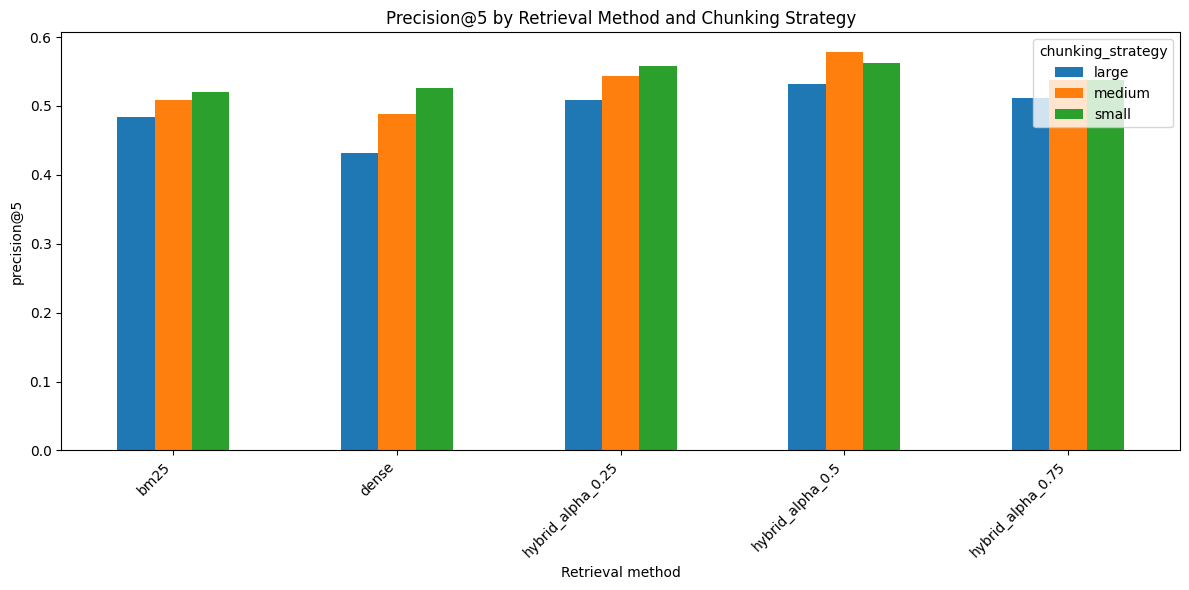

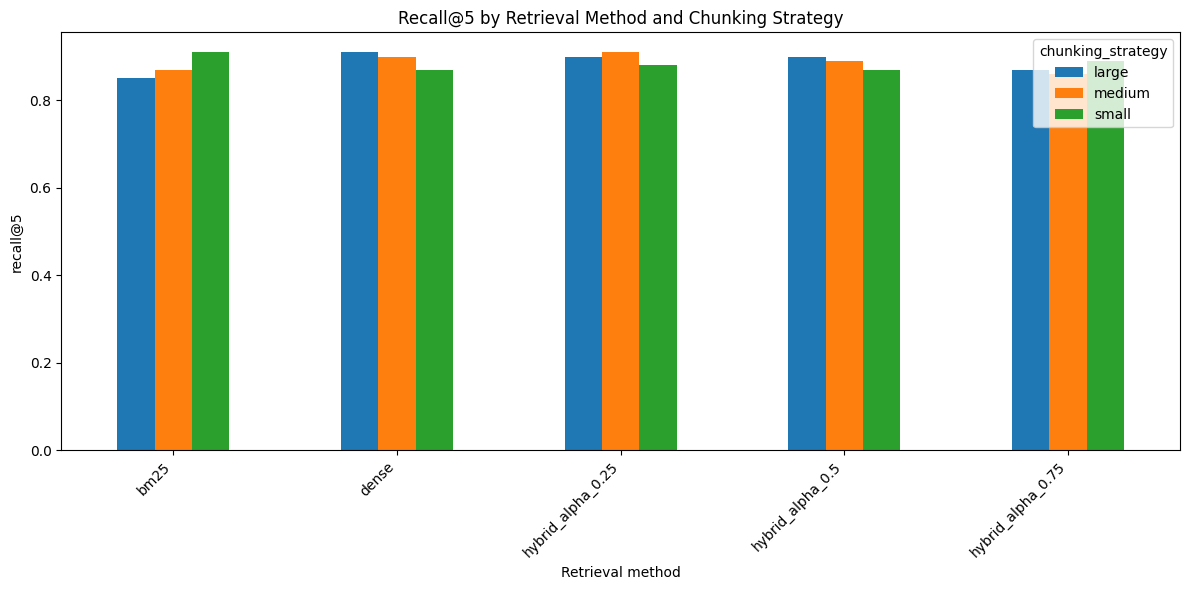

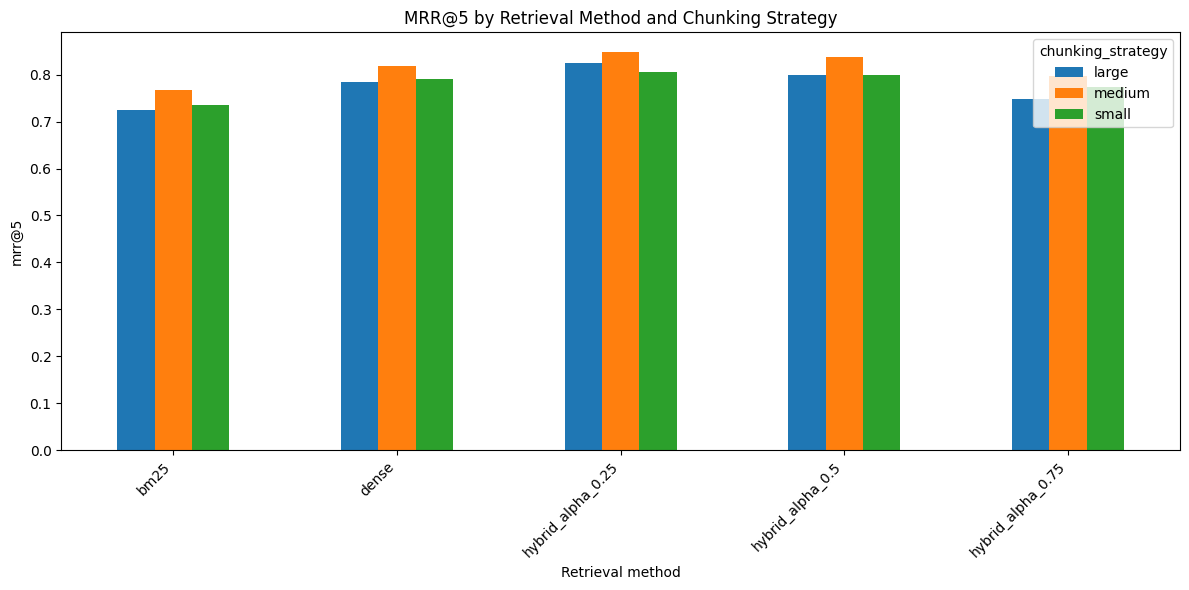

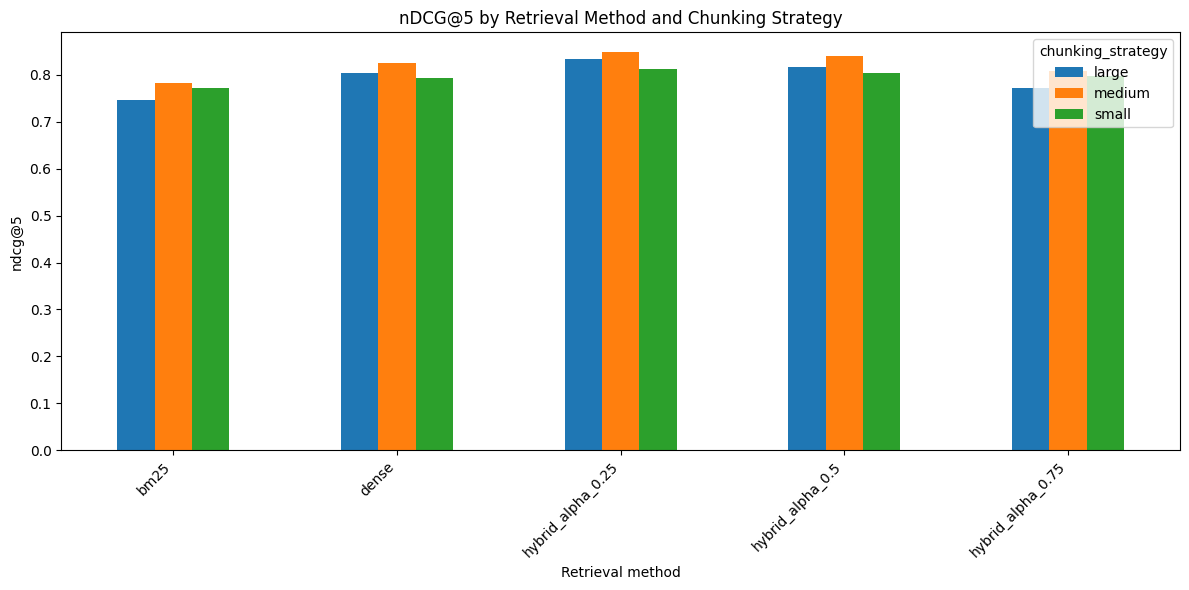

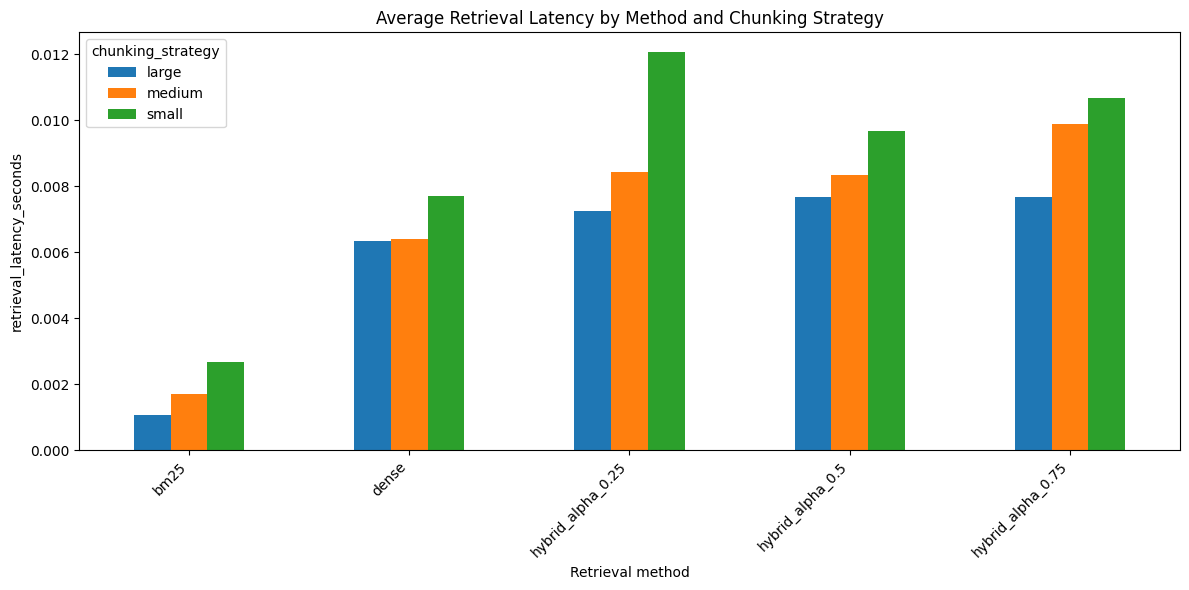

In [ ]:
def save_bar_plot(df, metric, filename, title):
    pivot = df.pivot(index="method", columns="chunking_strategy", values=metric)
    ax = pivot.plot(kind="bar", figsize=(12, 6))
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("Retrieval method")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(plots_path / filename, dpi=300)
    plt.show()

save_bar_plot(
    retrieval_summary,
    "precision@5",
    "precision_at_5_by_method.png",
    "Precision@5 by Retrieval Method and Chunking Strategy"
)

save_bar_plot(
    retrieval_summary,
    "recall@5",
    "recall_at_5_by_method.png",
    "Recall@5 by Retrieval Method and Chunking Strategy"
)

save_bar_plot(
    retrieval_summary,
    "mrr@5",
    "mrr_at_5_by_method.png",
    "MRR@5 by Retrieval Method and Chunking Strategy"
)

save_bar_plot(
    retrieval_summary,
    "ndcg@5",
    "ndcg_at_5_by_method.png",
    "nDCG@5 by Retrieval Method and Chunking Strategy"
)

save_bar_plot(
    retrieval_summary,
    "retrieval_latency_seconds",
    "retrieval_latency_by_method.png",
    "Average Retrieval Latency by Method and Chunking Strategy"
)

**Prepare Best Retriever**

In [ ]:
def build_retriever_by_name(chunks_df, method_name):
    bm25 = BM25Retriever(chunks_df)
    dense = DenseRetriever(chunks_df)

    if method_name == "bm25":
        return bm25

    if method_name == "dense":
        return dense

    if method_name.startswith("hybrid_alpha_"):
        alpha = float(method_name.replace("hybrid_alpha_", ""))
        return HybridRetriever(chunks_df, bm25, dense, alpha=alpha)

    raise ValueError("Unknown method name:", method_name)

chunks_for_best = chunk_sets[best_chunking_strategy]
best_retriever = build_retriever_by_name(chunks_for_best, best_method)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

**RAG answer generation**

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

GENERATION_MODEL = "google/flan-t5-base"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Generation device:", device)

tokenizer = AutoTokenizer.from_pretrained(GENERATION_MODEL)
generation_model = AutoModelForSeq2SeqLM.from_pretrained(GENERATION_MODEL).to(device)

def build_prompt(question, retrieved_chunks):
    context = "\n\n".join([
        f"Source {i+1}: {item['chunk_text']}"
        for i, item in enumerate(retrieved_chunks)
    ])

    prompt = f"""
You are answering questions about university academic regulations.
Use only the provided context.
If the answer is not available in the context, write: Not found in the provided context.

Context:
{context}

Question:
{question}

Answer:
"""
    return prompt, context

def generate_answer(prompt, max_input_tokens=1024, max_new_tokens=150):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_input_tokens
    ).to(device)

    with torch.no_grad():
        outputs = generation_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return clean_text(answer)

rag_rows = []

TOP_CONTEXT_K = 3

for _, row in tqdm(qa.iterrows(), total=len(qa)):
    question_id = row["question_id"]
    question = row["question"]
    reference_answer = row["reference_answer"]
    gold_doc_id = str(row["doc_id"])

    retrieved, _, retrieval_latency = best_retriever.retrieve(question, top_k=TOP_CONTEXT_K)
    prompt, context = build_prompt(question, retrieved)

    start_time = time.time()
    generated_answer = generate_answer(prompt)
    generation_latency = time.time() - start_time

    rag_rows.append({
        "question_id": question_id,
        "question": question,
        "reference_answer": reference_answer,
        "generated_answer": generated_answer,
        "gold_doc_id": gold_doc_id,
        "retrieval_method": best_method,
        "chunking_strategy": best_chunking_strategy,
        "top_context_k": TOP_CONTEXT_K,
        "retrieved_context": context,
        "retrieval_latency_seconds": retrieval_latency,
        "generation_latency_seconds": generation_latency
    })

rag_answers_df = pd.DataFrame(rag_rows)
rag_answers_df.to_csv(results_path / "rag_generated_answers.csv", index=False)

display(rag_answers_df.head())

Generation device: cuda


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

100%|██████████| 100/100 [01:08<00:00,  1.45it/s]


,question_id,question,reference_answer,generated_answer,gold_doc_id,retrieval_method,chunking_strategy,top_context_k,retrieved_context,retrieval_latency_seconds,generation_latency_seconds
0,Q001,What is the scope or applicability of Digital ...,5 § 1 Applicability of the examination regulat...,2 (4) and 64 (1) of the North Rhine-Westphalia...,D001,hybrid_alpha_0.25,medium,3,Source 1: Official Communication (Amtliche Mit...,0.013477,0.961242
1,Q002,What objectives or learning outcomes are descr...,5 § 2 Objectives of the program; purpose of ex...,"a) First, students enrolled in the programs “D...",D001,hybrid_alpha_0.25,medium,3,Source 1: asked and the number of questions an...,0.010798,0.678043
2,Q003,What academic degree or qualification is descr...,64/2021 Examination regulations for the progra...,Regulations for the programs Digital Sciences ...,D001,hybrid_alpha_0.25,medium,3,Source 1: regulations will come into force on ...,0.011636,0.408198
3,Q004,What duration or standard period of study is s...,6 § 4 Standard program duration (Regelstudienz...,"Master of Science of November 22, 2021",D001,hybrid_alpha_0.25,medium,3,Source 1: can be properly continued and comple...,0.014741,0.294556
4,Q005,What admission or prerequisite information is ...,5 § 3 Admission requirements ....................,3 Admission requirements,D001,hybrid_alpha_0.25,medium,3,Source 1: Science” is awarded in ac- cordance ...,0.012269,0.232440


**Answer quality evaluation**

In [ ]:
eval_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def sentence_split(text):
    text = str(text)
    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    return sentences

def semantic_similarity(a, b):
    emb = eval_model.encode([a, b], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))

def context_support_score(answer, context):
    answer_sentences = sentence_split(answer)

    if len(answer_sentences) == 0:
        return 0.0

    context_sentences = sentence_split(context)

    if len(context_sentences) == 0:
        return 0.0

    answer_emb = eval_model.encode(answer_sentences, normalize_embeddings=True)
    context_emb = eval_model.encode(context_sentences, normalize_embeddings=True)

    sim_matrix = np.dot(answer_emb, context_emb.T)
    max_support_per_sentence = sim_matrix.max(axis=1)

    return float(np.mean(max_support_per_sentence))

answer_eval_rows = []

for _, row in tqdm(rag_answers_df.iterrows(), total=len(rag_answers_df)):
    generated_answer = row["generated_answer"]
    reference_answer = row["reference_answer"]
    retrieved_context = row["retrieved_context"]

    ref_sim = semantic_similarity(generated_answer, reference_answer)
    support = context_support_score(generated_answer, retrieved_context)

    hallucination_flag = 1 if support < 0.45 else 0

    answer_eval_rows.append({
        "question_id": row["question_id"],
        "question": row["question"],
        "reference_answer": reference_answer,
        "generated_answer": generated_answer,
        "answer_reference_similarity": ref_sim,
        "context_support_score": support,
        "hallucination_flag": hallucination_flag,
        "retrieval_method": row["retrieval_method"],
        "chunking_strategy": row["chunking_strategy"],
        "retrieval_latency_seconds": row["retrieval_latency_seconds"],
        "generation_latency_seconds": row["generation_latency_seconds"]
    })

answer_eval_df = pd.DataFrame(answer_eval_rows)
answer_eval_df.to_csv(results_path / "rag_answer_evaluation.csv", index=False)

display(answer_eval_df.head())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:13<00:00,  7.47it/s]


,question_id,question,reference_answer,generated_answer,answer_reference_similarity,context_support_score,hallucination_flag,retrieval_method,chunking_strategy,retrieval_latency_seconds,generation_latency_seconds
0,Q001,What is the scope or applicability of Digital ...,5 § 1 Applicability of the examination regulat...,2 (4) and 64 (1) of the North Rhine-Westphalia...,0.360873,0.642385,0,hybrid_alpha_0.25,medium,0.013477,0.961242
1,Q002,What objectives or learning outcomes are descr...,5 § 2 Objectives of the program; purpose of ex...,"a) First, students enrolled in the programs “D...",0.471025,0.800171,0,hybrid_alpha_0.25,medium,0.010798,0.678043
2,Q003,What academic degree or qualification is descr...,64/2021 Examination regulations for the progra...,Regulations for the programs Digital Sciences ...,0.728966,0.738604,0,hybrid_alpha_0.25,medium,0.011636,0.408198
3,Q004,What duration or standard period of study is s...,6 § 4 Standard program duration (Regelstudienz...,"Master of Science of November 22, 2021",0.216398,0.495896,0,hybrid_alpha_0.25,medium,0.014741,0.294556
4,Q005,What admission or prerequisite information is ...,5 § 3 Admission requirements ....................,3 Admission requirements,0.644257,0.648408,0,hybrid_alpha_0.25,medium,0.012269,0.232440


**Answer quality summary**

In [ ]:
answer_quality_summary = pd.DataFrame({
    "metric": [
        "Average answer-reference semantic similarity",
        "Average context support score",
        "Estimated hallucination rate",
        "Average retrieval latency seconds",
        "Average generation latency seconds"
    ],
    "value": [
        answer_eval_df["answer_reference_similarity"].mean(),
        answer_eval_df["context_support_score"].mean(),
        answer_eval_df["hallucination_flag"].mean(),
        answer_eval_df["retrieval_latency_seconds"].mean(),
        answer_eval_df["generation_latency_seconds"].mean()
    ]
})

answer_quality_summary.to_csv(tables_path / "answer_quality_summary.csv", index=False)
display(answer_quality_summary)

,metric,value
0,Average answer-reference semantic similarity,0.312886
1,Average context support score,0.657164
2,Estimated hallucination rate,0.200000
3,Average retrieval latency seconds,0.012372
4,Average generation latency seconds,0.674541


**Plot answer quality results**

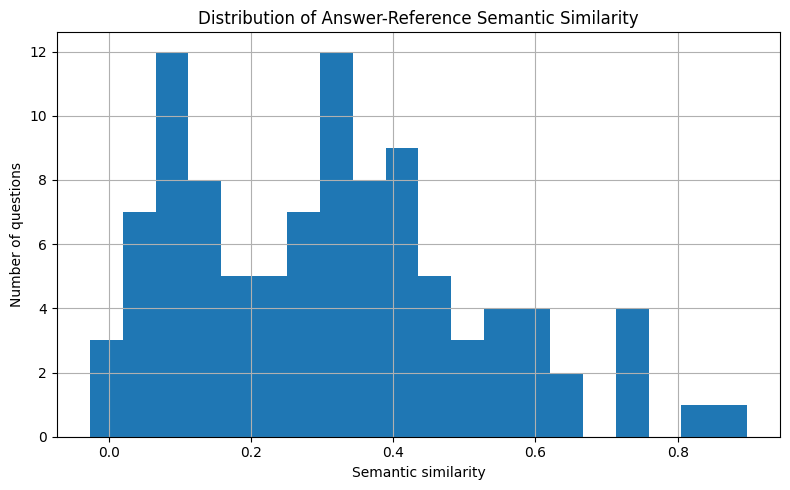

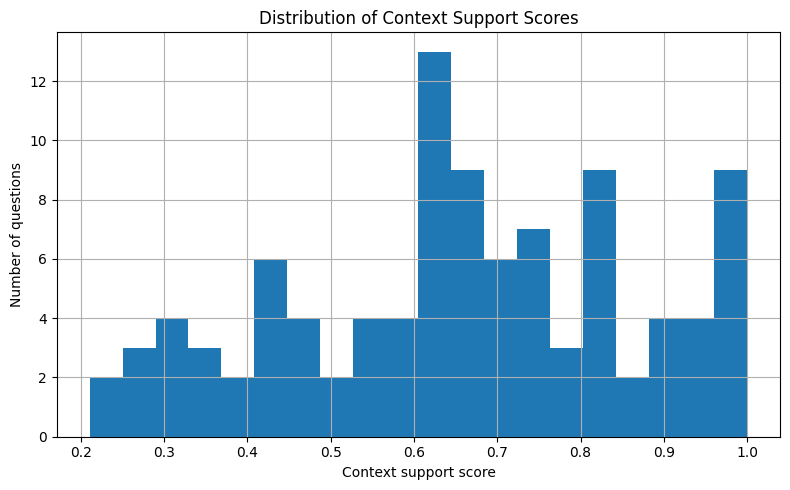

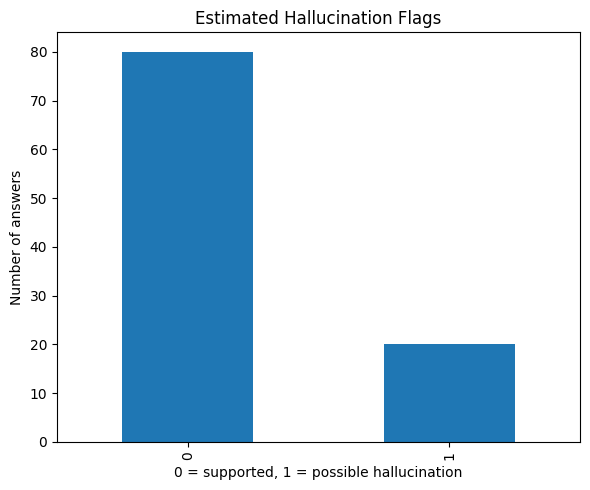

In [ ]:
plt.figure(figsize=(8, 5))
answer_eval_df["answer_reference_similarity"].hist(bins=20)
plt.title("Distribution of Answer-Reference Semantic Similarity")
plt.xlabel("Semantic similarity")
plt.ylabel("Number of questions")
plt.tight_layout()
plt.savefig(plots_path / "answer_reference_similarity_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
answer_eval_df["context_support_score"].hist(bins=20)
plt.title("Distribution of Context Support Scores")
plt.xlabel("Context support score")
plt.ylabel("Number of questions")
plt.tight_layout()
plt.savefig(plots_path / "context_support_score_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(6, 5))
answer_eval_df["hallucination_flag"].value_counts().sort_index().plot(kind="bar")
plt.title("Estimated Hallucination Flags")
plt.xlabel("0 = supported, 1 = possible hallucination")
plt.ylabel("Number of answers")
plt.tight_layout()
plt.savefig(plots_path / "hallucination_flags.png", dpi=300)
plt.show()

**Final result tables**

In [ ]:
# Best 10 and weakest 10 generated answers by semantic similarity
best_answers = answer_eval_df.sort_values(
    "answer_reference_similarity",
    ascending=False
).head(10)

weakest_answers = answer_eval_df.sort_values(
    "answer_reference_similarity",
    ascending=True
).head(10)

best_answers.to_csv(tables_path / "best_10_generated_answers.csv", index=False)
weakest_answers.to_csv(tables_path / "weakest_10_generated_answers.csv", index=False)

# Method ranking table
method_ranking = retrieval_summary.sort_values(
    by=["mrr@5", "recall@5", "precision@5"],
    ascending=False
)

method_ranking.to_csv(tables_path / "method_ranking_table.csv", index=False)

display(method_ranking.head(10))
display(best_answers[["question_id", "question", "reference_answer", "generated_answer", "answer_reference_similarity"]])
display(weakest_answers[["question_id", "question", "reference_answer", "generated_answer", "answer_reference_similarity"]])


,chunking_strategy,method,precision@1,recall@1,mrr@1,ndcg@1,precision@3,recall@3,mrr@3,ndcg@3,precision@5,recall@5,mrr@5,ndcg@5,retrieval_latency_seconds,index_build_time_seconds
7,medium,hybrid_alpha_0.25,0.81,0.81,0.81,0.81,0.613333,0.86,0.835000,0.834768,0.544,0.91,0.847500,0.847704,0.008440,0.000526
8,medium,hybrid_alpha_0.5,0.80,0.80,0.80,0.80,0.640000,0.87,0.831667,0.838782,0.578,0.89,0.836667,0.838723,0.008330,0.000375
2,large,hybrid_alpha_0.25,0.77,0.77,0.77,0.77,0.573333,0.89,0.823333,0.835302,0.508,0.90,0.825333,0.834362,0.007259,0.001669
6,medium,dense,0.78,0.78,0.78,0.78,0.570000,0.84,0.805000,0.806525,0.488,0.90,0.819000,0.824443,0.006404,7.874183
12,small,hybrid_alpha_0.25,0.75,0.75,0.75,0.75,0.623333,0.86,0.800000,0.810302,0.558,0.88,0.805000,0.812233,0.012060,0.000596
13,small,hybrid_alpha_0.5,0.75,0.75,0.75,0.75,0.600000,0.85,0.795000,0.806401,0.562,0.87,0.800000,0.804435,0.009682,0.000252
3,large,hybrid_alpha_0.5,0.73,0.73,0.73,0.73,0.586667,0.85,0.786667,0.796940,0.532,0.90,0.798167,0.815859,0.007684,0.000295
9,medium,hybrid_alpha_0.75,0.75,0.75,0.75,0.75,0.616667,0.85,0.795000,0.806757,0.538,0.86,0.797500,0.807524,0.009897,0.000387
11,small,dense,0.74,0.74,0.74,0.74,0.563333,0.83,0.781667,0.787565,0.526,0.87,0.790667,0.791942,0.007716,14.022639
1,large,dense,0.71,0.71,0.71,0.71,0.510000,0.86,0.771667,0.792026,0.432,0.91,0.783667,0.803465,0.006343,6.711065


,question_id,question,reference_answer,generated_answer,answer_reference_similarity
46,Q047,What academic degree or qualification is descr...,Degree Program and Examination Regulations for...,The following regulations define the objective...,0.897698
50,Q051,What academic degree or qualification is descr...,Can I do so after the semester has already beg...,SLcM Campus Management Student concerns (FAQs)...,0.837240
42,Q043,What admission or prerequisite information is ...,Section 10 Master’s Thesis (1) The aim of the ...,The following regulations define the objective...,0.747582
40,Q041,What is the scope or applicability of Critical...,Critical Dance Studies within the Department o...,The following regulations define the objective...,0.736252
2,Q003,What academic degree or qualification is descr...,64/2021 Examination regulations for the progra...,Regulations for the programs Digital Sciences ...,0.728966
62,Q063,What academic degree or qualification is descr...,The Computer Science and Cyber Security examin...,The Computer Science and Cybersecurity examina...,0.725959
4,Q005,What admission or prerequisite information is ...,5 § 3 Admission requirements ....................,3 Admission requirements,0.644257
66,Q067,What does Computer Science and Cybersecurity E...,INSTITUTE OF COMPUTER SCIENCE Examination offi...,The Computer Science and Cybersecurity examina...,0.626691
25,Q026,What is the scope or applicability of Geograph...,Geographies of Global Inequalities in the Depa...,Master’s Thesis Section 10 Electronic (Online)...,0.598443
85,Q086,What credit points or workload information is ...,Business Administration (Betriebswirtschaftsle...,"Lecture (3 credit hours), practical course (1 ...",0.595558


,question_id,question,reference_answer,generated_answer,answer_reference_similarity
11,Q012,What objectives or learning outcomes are descr...,Sustainability Learning objectives of foreign ...,Kowalski,-0.026645
97,Q098,Which Campus Management FAQ topic addresses re...,The Student concerns FAQ includes the question...,Literature,-0.005327
67,Q068,What is the scope or applicability of MA Engli...,You can apply before completing your first (un...,MA English Literatures and Cultures,0.008054
75,Q076,What duration or standard period of study is s...,Section 2 Regular period of study The regular ...,module,0.030318
90,Q091,What does Information for Enrolled Students in...,"Content The core elements Regulations, module ...",Your program is in cluster 2.,0.031721
16,Q017,What does Examination Management in CaMS state...,This may affect registrations for examinations...,TH Köln,0.035160
87,Q088,What is the scope or applicability of Informat...,The Campus Center is there to help internation...,The total work load 6 credit points,0.044793
12,Q013,What academic degree or qualification is descr...,Weight of the result within the final result T...,International Business,0.049552
78,Q079,What objectives or learning outcomes are descr...,7 Introduction ..................................,Elective Modules,0.051352
13,Q014,What duration or standard period of study is s...,Semester Duration One semester Frequency Offer...,Module 4.02.,0.064901


Final ZIP

In [ ]:
import os

final_zip_path = "/content/chapter4_results_submission_ready.zip"

if os.path.exists(final_zip_path):
    os.remove(final_zip_path)

shutil.make_archive(
    base_name="/content/chapter4_results_submission_ready",
    format="zip",
    root_dir=results_path
)

print("Final Chapter 4 results ZIP created:")
print(final_zip_path)

files.download(final_zip_path)

Final Chapter 4 results ZIP created:
/content/chapter4_results_submission_ready.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>